## Avaliação Empírica da Melhoria do Algoritmo KNN

Para fazer uma avaliação do algoritmo para os datasets originais, com adição de ruido e de noise, analisamos as **métricas de desempenho** - accuracy, precision, recall, f1-score, a **influência de diferentes níveis de outliers e noise**, a **influência do hiperparâmetro k** na performance e os resultados do **k-fold cross-validation**.

Começamos por juntar as duas funções de **_predict** feitas anteriormente.

In [1]:
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

# Função euclidiana
def euclidean_fun(x1,x2):
    distance = np.sqrt(np.sum((x1-x2)**2))
    return distance


class KNN:
    # Definir o k
    def __init__(self, k, mzs = False):
        self.k = None if k == 0 else k
        self.mzs = mzs
    
    # Função de treino (armazena os dados)
    def fit(self, X,y):
        self.X_train = X   # matriz de caracteristicas
        self.y_train = y   # vetor com as classes correspondentes

    # Prevê
    def predict(self,X):
        if self.mzs:
            return [self._predict_mzs(x) for x in X]
        else:
            return [self._predict(x) for x in X]
    
    def _predict(self, x):
        # Calcula as distâncias de cada exemplo ao ponto x
        distances = [euclidean_fun(x, x_train) for x_train in self.X_train]

        # Vai buscar os k valores mais próximos
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # Vê qual é a classe mais comum entre os k escolhidos
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

    def _predict_mzs(self, x):
        # Calcula as distâncias de cada exemplo ao ponto x
        distances = [euclidean_fun(x, x_train) for x_train in self.X_train]

        # Vai buscar os k valores mais próximos e ordena-os pelas distancias
        k_indices = np.argsort(distances)[:self.k]
        # Extrai as classes
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        # Extrai as distâncias
        k_nearest_distances = [distances[i] for i in k_indices]

        # Modified Z-score
        dists = np.array(k_nearest_distances)
        # Distância mediana dos vizinhos
        median_dist = np.median(dists)
        # Mediana do desvio absoluto
        mad = np.median(np.abs(dists - median_dist))
        mad = mad if mad > 0 else 1e-6

        # Modified Z-score -> mede o quão "fora do normal" está cada distância em relação à mediana
        mod_z = 0.6745 * (dists - median_dist) / mad

        # Colocar pesos a cada um dos vizinhos, penalizando os que estão mais longe comparado à maioria
        weights_z = 1.0 / (1.0 + np.abs(mod_z))     # quando maior o Z-score, menor o peso (função inversa)
        weights_dist = 1.0 / (dists + 1e-6)     # quanto maior a distância, menor o peso
        weights = weights_z * weights_dist      # multiplicação dos dois, vizinhos normais e proximos teem mais influência

        # soma dos pesos dos k vizinhos com a mesma classe
        class_weights = defaultdict(float)
        for label, weight in zip(k_nearest_labels, weights):
            class_weights[label] += weight

        # a classe com maior pesos é escolhida como previsão
        predicted_label = max(class_weights, key = class_weights.get)
        return predicted_label

In [2]:
def noise(y, nivel_noise):
    y_noisy = y.copy()
    n = int(nivel_noise * len(y)) # calculo de quantos elementos do vetor vão ser alterados conforme o nível de noise que se introduz
    indices = np.random.choice(len(y), n, replace=False) # escolhe aleatoriamente n linhas diferentes para alterar (replace = False impede repetições) 
    for i in indices:   # para cada indice
        current = y_noisy[i]    # guarda a classe atual
        other_classes = list(set(y_noisy) - {current})  # cria uma lista de todas as classes diferentes da atual
        if other_classes:   # se a lista não for nula
            y_noisy[i] = np.random.choice(other_classes)   # altera para uma outra classe
    return y_noisy

In [3]:
def outliers(X, y, nivel_outliers, magnitude=10.0): # magnitude = até quanto queremos "sair" dos limites normais para gerar outliers
    n_outliers = int(len(X) * nivel_outliers)   # calcula quantos outliers vão ser criados
    n_features = X.shape[1] # conta o n de atributos que cada exemplo tem
    
    # define um intervalo de valores extremo para gerar os outliers
    # usa o 5º percentil como limite inferior
    low = np.percentile(X, 5) - magnitude
    # usa o 95º percentil como limite superior
    high = np.percentile(X, 95) + magnitude

    # gera n_outliers exemplos aleatorios com valores entre o low e o high
    outlier_X = np.random.uniform(
        low=low,
        high=high,
        size=(n_outliers, n_features)   # cada outlier tem n_features atribuidos
    )

    unique_labels = np.unique(y)    # encontra todos os valores diferentes que existem em y (classes)
    outlier_y = np.random.choice(unique_labels, size=n_outliers)    # escolhe aleatoriamente uma classe para cada um dos novos outliers
    
    # junta os novos outliers ao dataset original
    new_X = np.vstack((X, outlier_X))
    new_y = np.hstack((y, outlier_y))
    
    return new_X, new_y

In [4]:
def metricas(y_true, y_predicted):
    unique_labels = np.unique(np.concatenate((y_true, y_predicted)))    # junta as classes true e predicted e encontra todas 

    classe_negativa, classe_positiva = sorted(unique_labels)  # organiza por ordem crescente qual é a classe negativa e a positiva

    TP = FP = FN = TN = 0   # inicializa os contadores
    for true, predicted in zip(y_true, y_predicted):
        if true == classe_positiva and predicted == classe_positiva:
            TP += 1
        elif true == classe_negativa and predicted == classe_positiva:
            FP += 1
        elif true == classe_positiva and predicted == classe_negativa:
            FN += 1
        elif true == classe_negativa and predicted == classe_negativa:
            TN += 1

    accuracy  = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score  = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return accuracy, precision, recall, f1_score

Para facilitar a comparação e análise dos resultados obtidos, optámos por substituir o gráfico de colunas original por um **gráfico de linhas**, que permite uma visualização mais clara da variação das métricas entre os diferentes cenários. Cada linha do gráfico representa um dos seguintes conjuntos de dados avaliados:
- Dataset Original
- Dataset Original + Modified Z-Score — aplicação do algoritmo KNN com pesos baseados no Modified Z-Score, sem alterações aos dados.
- Dataset com Outliers
- Dataset com Outliers + Modified Z-Score
- Dataset com Noise
- Dataset com Noise + Modified Z-Score

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def grafico_metricas(orig, orig_mzs, out, out_mzs, noise, noise_mzs):
    nomes_metricas = ["Accuracy", "F1-Score"]

    dados = {
        "Original": [orig[0], orig[3]],
        "Original + MZS": [orig_mzs[0], orig_mzs[3]],
        "Outliers": [out[0], out[3]],
        "Outliers + MZS": [out_mzs[0], out_mzs[3]],
        "Noise": [noise[0], noise[3]],
        "Noise + MZS": [noise_mzs[0], noise_mzs[3]]
    }

    x = np.arange(len(nomes_metricas))  # [0, 1] para Accuracy e F1-score
    width = 0.1  # Largura de cada barra
    espacamento = 0.25  # espaço entre grupos

    fig, ax = plt.subplots(figsize=(10, 5))

    # Cores organizadas por grupos (claro + escuro)
    cores = ['#66b3ff', '#0059b3',   # azul claro / escuro
             '#ffcc99', '#cc6600',   # laranja claro / escuro
             '#99ff99', '#339933']   # verde claro / escuro

    grupos = list(dados.items())
    for i in range(3):  # 3 grupos: Original, Outliers, Noise
        label_1, valores_1 = grupos[2*i]
        label_2, valores_2 = grupos[2*i + 1]

        pos = x + i * espacamento

        
        rects1 = ax.bar(pos - width/2, valores_1, width, label=label_1, color=cores[2*i])
        for j in range(len(valores_1)):
            ax.text(pos[j] - width/2, valores_1[j] + 0.01, f'{valores_1[j]:.3f}',
                    ha='center', va='bottom', fontsize=8)

       
        rects2 = ax.bar(pos + width/2, valores_2, width, label=label_2, color=cores[2*i+1])
        for j in range(len(valores_2)):
            ax.text(pos[j] + width/2, valores_2[j] + 0.01, f'{valores_2[j]:.3f}',
                    ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x + espacamento)
    ax.set_xticklabels(nomes_metricas)
    ax.set_ylabel("Valor")
    ax.set_title("Comparação de Accuracy e F1-score Para o Algoritmo Com e Sem o Modified Z-Score")
    ax.set_ylim(0, 1.05)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


Implementamos também uma função para conseguirmos analisar o **impacto que diferentes níveis de noise e outliers** têm no algoritmo com e sem a implementação do Modified Z-score.

Esta função retorna 4 *gráficos de linhas*: 
- Gráfico da Accuracy para diferentes valores de outliers
- Gráfico do F1-Score para diferentes valores de outliers
- Gráfico da Accuracy para diferentes valores de noise
- Gráfico do F1-Score para diferentes valores de noise

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def grafico_impacto_noise_outliers(X_train, y_train, X_test, y_test, tipo="noise", k=5, niveis=np.arange(0, 0.6, 0.1), magnitude=10):

    acc_simples = []
    acc_mzs = []
    f1_simples = []
    f1_mzs = []

    for nivel in niveis:
        if tipo == "noise":
            y_mod = noise(y_train, nivel)
            X_mod = X_train.copy()
        elif tipo == "outliers":
            X_mod, y_mod = outliers(X_train, y_train, nivel, magnitude)
        else:
            raise ValueError("tipo deve ser 'noise' ou 'outliers'")

        # KNN simples
        modelo = KNN(k=k, mzs=False)
        modelo.fit(X_mod, y_mod)
        preds = modelo.predict(X_test)
        acc, _, _, f1 = metricas(y_test, preds)
        acc_simples.append(acc)
        f1_simples.append(f1)

        # KNN com Modified Z-Score
        modelo_mzs = KNN(k=k, mzs=True)
        modelo_mzs.fit(X_mod, y_mod)
        preds_mzs = modelo_mzs.predict(X_test)
        acc_m, _, _, f1_m = metricas(y_test, preds_mzs)
        acc_mzs.append(acc_m)
        f1_mzs.append(f1_m)

    # Gráfico Accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(niveis, acc_simples, marker='o', label="KNN", color='tab:blue')
    plt.plot(niveis, acc_mzs, marker='o', label="KNN + MZS", color='tab:orange')
    plt.title(f"Variação da Accuracy com Níveis de {tipo.capitalize()}")
    plt.xlabel(f"Nível de {tipo}")
    plt.ylabel("Accuracy")
    plt.yticks(np.arange(0.4, 0.91, 0.1))  # De 0.4 a 0.9
    plt.ylim(0.4, 0.9)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Gráfico F1-Score
    plt.figure(figsize=(8, 5))
    plt.plot(niveis, f1_simples, marker='o', label='KNN', color='tab:blue')
    plt.plot(niveis, f1_mzs, marker='o', label='KNN + MZS', color='tab:orange')
    plt.title(f"Variação do F1-Score com Níveis de {tipo.capitalize()}")
    plt.xlabel(f"Nível de {tipo}")
    plt.ylabel("F1-Score")
    plt.yticks(np.arange(0.4, 0.91, 0.1))  # De 0.4 a 0.9
    plt.ylim(0.4, 0.9)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()


Com o objetivo de analisar o **impacto do hiperparâmetro k** no desempenho do algoritmo KNN, implementámos uma função que gera um *gráfico de linhas* que representa a variação da accuracy para diferentes valores de k, nos seis diferentes cenários.

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def grafico_k(X_train, y_train, X_test, y_test, k_values, nivel_noise, nivel_outliers, magnitude=10):

    accuracies = {
        "Original": [],
        "Original + MZS": [],
        "Outliers": [],
        "Outliers + MZS": [],
        "Noise": [],
        "Noise + MZS": []
    }

    y_noise = noise(y_train, nivel_noise)
    X_out, y_out = outliers(X_train, y_train, nivel_outliers, magnitude)

    for k in k_values:
        for label, (X, y, mzs) in {
            "Original": (X_train, y_train, False),
            "Original + MZS": (X_train, y_train, True),
            "Outliers": (X_out, y_out, False),
            "Outliers + MZS": (X_out, y_out, True),
            "Noise": (X_train, y_noise, False),
            "Noise + MZS": (X_train, y_noise, True)
        }.items():
            modelo = KNN(k=k, mzs=mzs)
            modelo.fit(X, y)
            preds = modelo.predict(X_test)
            acc, _, _, _ = metricas(y_test, preds)
            accuracies[label].append(acc)

    # Gráfico
    plt.figure(figsize=(10, 6))
    for label, values in accuracies.items():
        plt.plot(k_values, values, marker='o', label=label)

    plt.title("Variação da Accuracy para diferentes valores de k")
    plt.xlabel("Valor de k")
    plt.ylabel("Accuracy")
    plt.xticks(k_values)
    plt.yticks(np.arange(0.4, 0.91, 0.1))  # De 0.4 a 0.9 com passo 0.1
    plt.ylim(0.4, 0.9)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()


Implementamos também o  **K-Fold Cross-Validation** para avaliar o desempenho do algoritmo KNN em diferentes cenários: com e sem noise, com e sem outliers, e com e sem aplicação do Modified Z-Score. 
O objetivo é obter uma estimativa mais robusta do desempenho médio do modelo, complementada com o desvio padrão, para podermos entender melhor como o modelo se comporta.

In [8]:
def cross_validation(X, y, k_folds, nivel_noise, nivel_outliers, magnitude=10):
    
    # Dividir o dataset em k folds
    def split_kfold(X, y, k):
        n = len(X)
        indices = np.arange(n)
        # Baralhar os dados
        np.random.seed(42)
        np.random.shuffle(indices)
        # Garantir que os folds têm o mesmo tamanho
        fold_sizes = np.full(k, n // k)
        fold_sizes[:n % k] += 1

        current = 0
        # Dividir os indices em k pares de treino/teste
        folds = []
        for fold_size in fold_sizes:
            start, stop = current, current + fold_size
            test_idx = indices[start:stop]
            train_idx = np.concatenate((indices[:start], indices[stop:]))
            folds.append((train_idx, test_idx))
            current = stop
        return folds

    cenarios = {
        "Original": (False, lambda X, y: (X, y)),
        "Original + MZS": (True, lambda X, y: (X, y)),
        "Outliers": (False, lambda X, y: outliers(X, y, nivel_outliers, magnitude)),
        "Outliers + MZS": (True, lambda X, y: outliers(X, y, nivel_outliers, magnitude)),
        "Noise": (False, lambda X, y: (X, noise(y, nivel_noise))),
        "Noise + MZS": (True, lambda X, y: (X, noise(y, nivel_noise))),
    }

    resultados = []

    folds = split_kfold(X, y, k_folds)

    for nome, (mzs, transform_func) in cenarios.items():
        accs, precs, recs, f1s = [], [], [], []

        for train_idx, test_idx in folds:
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            X_mod, y_mod = transform_func(X_train, y_train)

            modelo = KNN(k=5, mzs=mzs)
            modelo.fit(X_mod, y_mod)
            preds = modelo.predict(X_test)

            acc, prec, rec, f1 = metricas(y_test, preds)
            accs.append(acc)
            precs.append(prec)
            recs.append(rec)
            f1s.append(f1)

        resultados.append({
            "Cenário": nome,
            "Accuracy": f"{np.mean(accs):.3f} ± {np.std(accs):.3f}",
            "Precision": f"{np.mean(precs):.3f} ± {np.std(precs):.3f}",
            "Recall": f"{np.mean(recs):.3f} ± {np.std(recs):.3f}",
            "F1-score": f"{np.mean(f1s):.3f} ± {np.std(f1s):.3f}",
        })

    return pd.DataFrame(resultados)


Para percebermos o verdadeiro impacto da melhoria que fizemos ao algoritmo, fizemos os seguintes **testes estatísticos**:
- T-test
- Teste de Wilcoxon
- Teste de Friedman

Esta função retorna os valores de *p*.

In [9]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel, wilcoxon, friedmanchisquare

def testes_estatisticos(preds_dict, y_true):
    print("\nTestes Estatísticos (entre cada par de métodos):\n")

    metodos = list(preds_dict.keys())
    
    # Comparar todas as combinações possíveis de pares de métodos
    for i in range(len(metodos)):
        for j in range(i + 1, len(metodos)):
            m1, m2 = metodos[i], metodos[j]
            y1 = preds_dict[m1]
            y2 = preds_dict[m2]

            # Converter para arrays binários de acertos (1 se acertou, 0 se errou)
            acertos1 = (np.array(y1) == np.array(y_true)).astype(int)
            acertos2 = (np.array(y2) == np.array(y_true)).astype(int)

            # T-test pareado
            t_stat, p_val_t = ttest_rel(acertos1, acertos2)

            # Teste de Wilcoxon
            try:
                w_stat, p_val_w = wilcoxon(acertos1, acertos2)
            except ValueError:
                w_stat, p_val_w = np.nan, np.nan

            print(f"{m1} vs {m2}:")
            print(f" - t-test pareado:     p = {p_val_t:.4f}")
            print(f" - Wilcoxon test:      p = {p_val_w:.4f}\n")

    # Teste de Friedman para os 6 métodos
    print("Teste de Friedman (6 métodos):")
    acertos = [np.array(preds_dict[m]) == np.array(y_true) for m in metodos]
    fried_stat, fried_p = friedmanchisquare(*acertos)
    print(f" - p = {fried_p:.4f}")



In [10]:
def celulas_vazias(X):
    # remover colunas todas a NaN
    X = X[:, ~np.isnan(X).all(axis=0)]

    # se ainda existirem celulas vazias:
    if np.isnan(X).any():
        col_means = np.nanmean(X, axis=0)   # faz a média
        inds = np.where(np.isnan(X))    # encontra os indices onde existem NaN
        X[inds] = np.take(col_means, inds[1])   # substitui pelo valor médio
    
    return X

Insira o path do dataset:  /home/ana/Desktop/AC I/Projeto/noise_outliers/dataset_451_irish.csv
Insira o nível de noise (entre 0 e 1):  0.3
Insira o nível de outliers (entre 0 e 1):  0.3


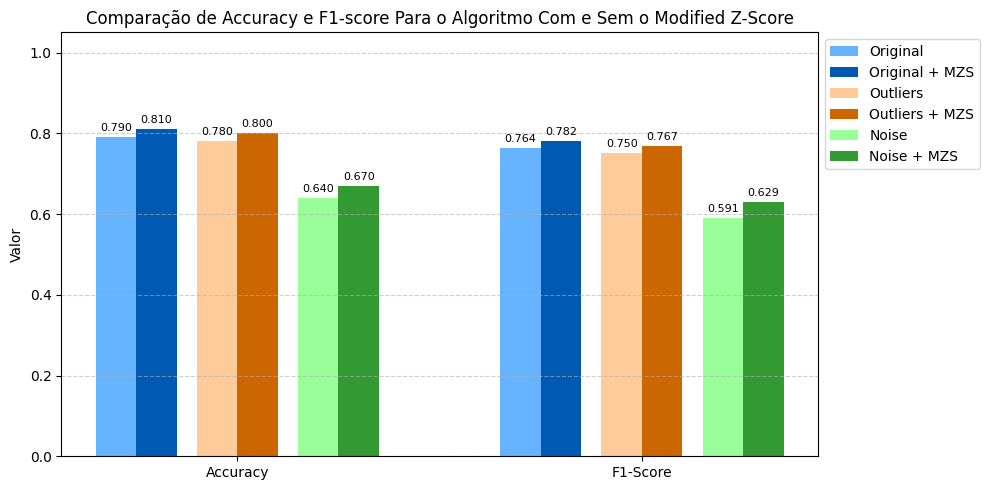

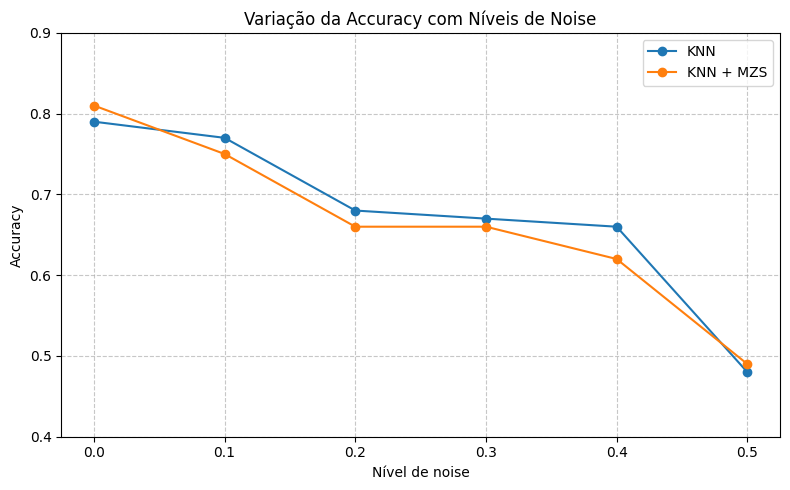

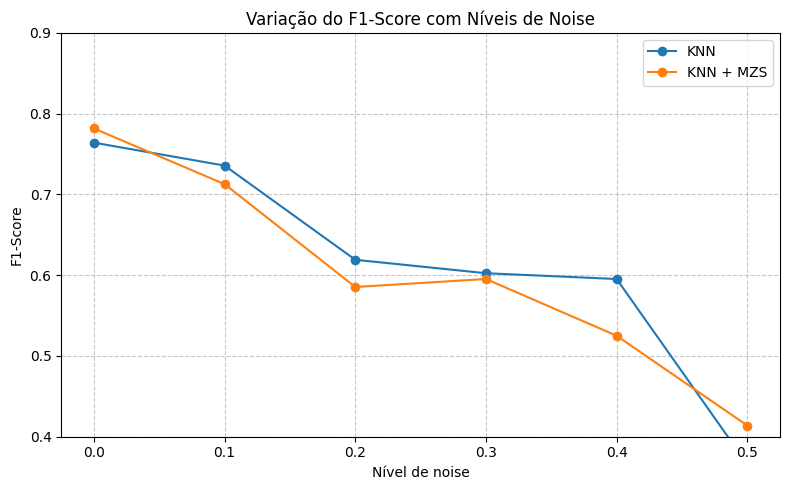

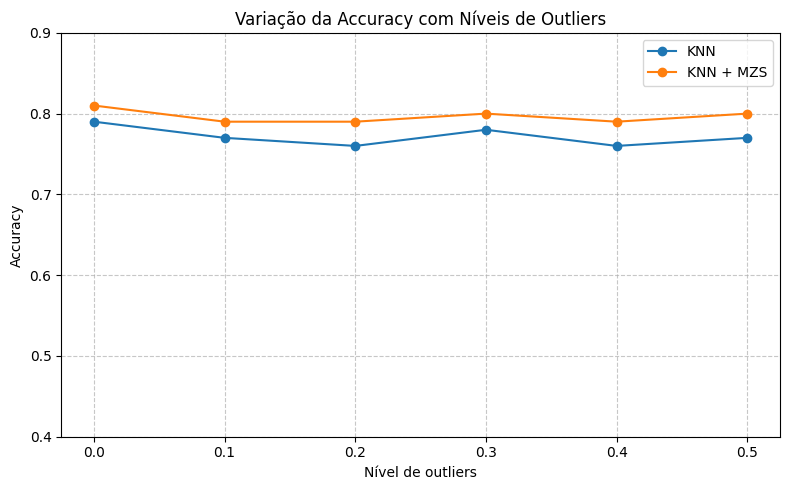

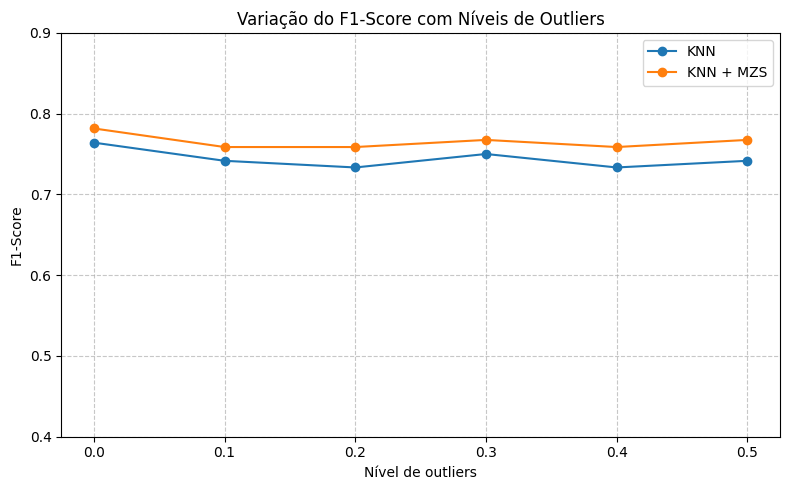

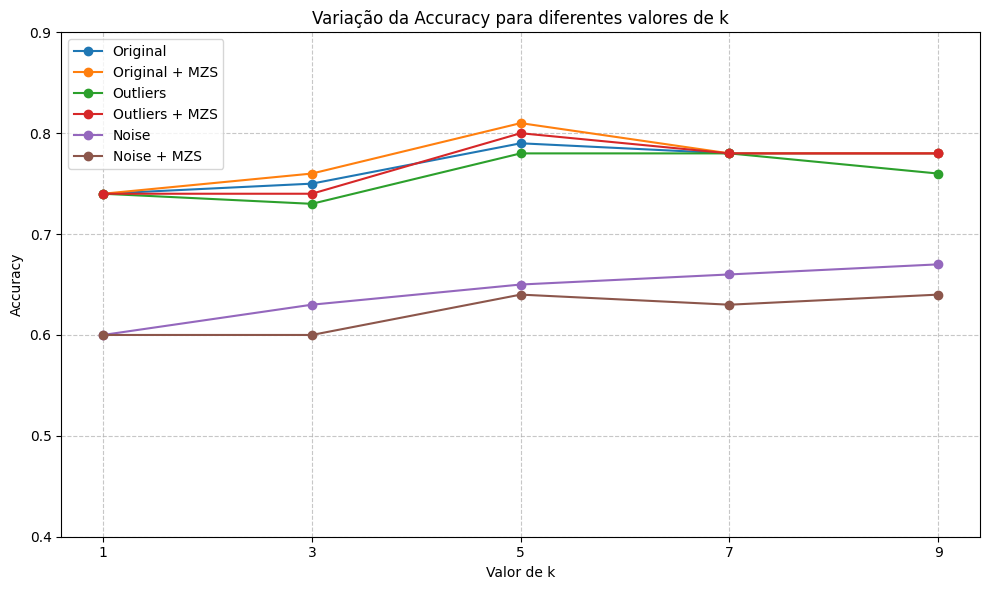


 Resultados do Cross-Validation (média ± desvio padrão)
       Cenário      Accuracy     Precision        Recall      F1-score
      Original 0.734 ± 0.036 0.713 ± 0.079 0.671 ± 0.069 0.688 ± 0.058
Original + MZS 0.736 ± 0.021 0.713 ± 0.070 0.680 ± 0.032 0.694 ± 0.036
      Outliers 0.730 ± 0.036 0.708 ± 0.075 0.667 ± 0.074 0.683 ± 0.058
Outliers + MZS 0.736 ± 0.022 0.715 ± 0.069 0.676 ± 0.036 0.693 ± 0.036
         Noise 0.626 ± 0.024 0.567 ± 0.045 0.673 ± 0.069 0.613 ± 0.037
   Noise + MZS 0.580 ± 0.038 0.525 ± 0.022 0.597 ± 0.032 0.558 ± 0.015

Testes Estatísticos (entre cada par de métodos):

Original vs Original + MZS:
 - t-test pareado:     p = 0.1583
 - Wilcoxon test:      p = 0.1573

Original vs Outliers:
 - t-test pareado:     p = 0.3197
 - Wilcoxon test:      p = 0.3173

Original vs Outliers + MZS:
 - t-test pareado:     p = 0.5663
 - Wilcoxon test:      p = 0.5637

Original vs Noise:
 - t-test pareado:     p = 0.0155
 - Wilcoxon test:      p = 0.0163

Original vs Noise + MZ

In [11]:
dataset = input("Insira o path do dataset: ")
nivel_noise = float(input("Insira o nível de noise (entre 0 e 1): "))
nivel_outliers = float(input("Insira o nível de outliers (entre 0 e 1): "))

df = pd.read_csv(dataset)

y = df.iloc[:, -1].values   # y contem os valores da última coluna = classe
X = pd.get_dummies(df.iloc[:, :-1]).values.astype(float)    # X fica com todas as colunas menos a última, usa get_dummies() para fazer One-Hot Encoding

X = celulas_vazias(X)

indices = np.arange(len(X))
np.random.seed(42)  # faz com que o embaralhamento seja sempre o mesmo quando se corre o código
np.random.shuffle(indices)  # embaralha a ordem dos indices
# reorganiza os dados
X = X[indices]
y = y[indices]

# dividir o dataset em 80% treino e 20% teste
split_idx = int(0.8 * len(X))
X_train = X[:split_idx]
y_train = y[:split_idx]
X_test = X[split_idx:]
y_test = y[split_idx:]

# ------------------------------
# Dataset sem alterações
modelo = KNN(k=5)
modelo.fit(X_train, y_train)
prediction = modelo.predict(X_test)
accuracy, precision, recall, f1_score = metricas(y_test, prediction)

# Dataset sem alterações com o MZS
modelo_mzs = KNN(k=5, mzs=True)
modelo_mzs.fit(X_train, y_train)
prediction_mzs = modelo_mzs.predict(X_test)
accuracy_mzs, precision_mzs, recall_mzs, f1_mzs = metricas(y_test, prediction_mzs)

# ------------------------------
# Dataset com noise
y_noise = noise(y_train, nivel_noise)
modelo_noise = KNN(k=5)
modelo_noise.fit(X_train, y_noise)
prediction_noise = modelo_noise.predict(X_test)
accuracy_noise, precision_noise, recall_noise, f1_noise = metricas(y_test, prediction_noise)

# Dataset com noise com o MZS
modelo_noise_mzs = KNN(k=5, mzs=True)
modelo_noise_mzs.fit(X_train, y_noise)
prediction_noise_mzs = modelo_noise_mzs.predict(X_test)
accuracy_noise_mzs, precision_noise_mzs, recall_noise_mzs, f1_noise_mzs = metricas(y_test, prediction_noise_mzs)

# ------------------------------
# Dataset com outliers
X_outliers, y_outliers = outliers(X_train, y_train, nivel_outliers, magnitude=10)
modelo_outliers = KNN(k=5)
modelo_outliers.fit(X_outliers, y_outliers)
prediction_outliers = modelo_outliers.predict(X_test)
accuracy_outliers, precision_outliers, recall_outliers, f1_outliers = metricas(y_test, prediction_outliers)

# Dataset com outliers com o MZS
modelo_outliers_mzs = KNN(k=5, mzs=True)
modelo_outliers_mzs.fit(X_outliers, y_outliers)
prediction_outliers_mzs = modelo_outliers_mzs.predict(X_test)
accuracy_outliers_mzs, precision_outliers_mzs, recall_outliers_mzs, f1_outliers_mzs = metricas(y_test, prediction_outliers_mzs)


# ------------------------------
# Gráfico de comparação
grafico_metricas(
    orig=[accuracy, precision, recall, f1_score],
    orig_mzs=[accuracy_mzs, precision_mzs, recall_mzs, f1_mzs],
    out=[accuracy_outliers, precision_outliers, recall_outliers, f1_outliers],
    out_mzs=[accuracy_outliers_mzs, precision_outliers_mzs, recall_outliers_mzs, f1_outliers_mzs],
    noise=[accuracy_noise, precision_noise, recall_noise, f1_noise],
    noise_mzs=[accuracy_noise_mzs, precision_noise_mzs, recall_noise_mzs, f1_noise_mzs]
)

#------------------------------
# Gráfico dos diferentes níveis de noise e outliers
grafico_impacto_noise_outliers(X_train, y_train, X_test, y_test, tipo="noise")
grafico_impacto_noise_outliers(X_train, y_train, X_test, y_test, tipo="outliers")


# ------------------------------
# Gráfico dos diferentes valores de k
grafico_k(X_train, y_train, X_test, y_test, k_values=range(1, 11, 2), nivel_noise=nivel_noise, nivel_outliers=nivel_outliers)


# ------------------------------
# Tabela K-folds Cross-validation
tabela_cv = cross_validation(X, y, k_folds=5, nivel_noise=nivel_noise, nivel_outliers=nivel_outliers)
print("\n Resultados do Cross-Validation (média ± desvio padrão)")
print(tabela_cv.to_string(index=False))


# ------------------------------
# Testes Estatísticos
preds_dict = {
    "Original": prediction,
    "Original + MZS": prediction_mzs,
    "Outliers": prediction_outliers,
    "Outliers + MZS": prediction_outliers_mzs,
    "Noise": prediction_noise,
    "Noise + MZS": prediction_noise_mzs
}

testes_estatisticos(preds_dict, y_test)
